# Capstone Project 5: Business-First Data Science Project

## Loan Approval Prediction System

### Objective

The objective of this project is to build a machine learning model that predicts whether a loan application should be approved based on applicant information.

This project demonstrates an end-to-end data science workflow from business understanding to business insights.

# Business Problem

Banks receive thousands of loan applications every year.

Approving loans for applicants who may default can lead to financial losses.

The goal is to build a predictive model that assists banks in making informed loan approval decisions.

# Project Workflow

1. Business Understanding
2. Data Collection
3. Data Cleaning
4. Exploratory Data Analysis
5. Feature Engineering
6. Data Preprocessing
7. Train-Test Split
8. Model Training
9. Model Evaluation
10. Business Insights

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

%matplotlib inline

In [2]:
df = pd.read_csv("../data/train_u6lujuX_CVtuZ9i.csv")

In [3]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [5]:
df.describe(include="all")

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614,601,611,599,614,582,614.000000,614.000000,592.000000,600.00000,564.000000,614,614
unique,614,2,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,2
top,LP001002,Male,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,Semiurban,Y
freq,1,489,398,345,480,500,NaN,NaN,NaN,NaN,NaN,233,422
mean,NaN,NaN,NaN,NaN,NaN,NaN,5403.459283,1621.245798,146.412162,342.00000,0.842199,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,6109.041673,2926.248369,85.587325,65.12041,0.364878,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,150.000000,0.000000,9.000000,12.00000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2877.500000,0.000000,100.000000,360.00000,1.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,3812.500000,1188.500000,128.000000,360.00000,1.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,5795.000000,2297.250000,168.000000,360.00000,1.000000,NaN,NaN


# Dataset Overview

The dataset contains applicant information such as:

- Gender
- Marital Status
- Education
- Income
- Loan Amount
- Credit History

The target variable is **Loan_Status**.

# Data Cleaning

The dataset is cleaned before model training.

The following preprocessing steps are performed:

- Handle missing values
- Remove unnecessary columns
- Encode categorical variables

In [6]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [7]:
for column in df.select_dtypes(include="object").columns:
    df[column] = df[column].fillna(df[column].mode()[0])

for column in df.select_dtypes(include=np.number).columns:
    df[column] = df[column].fillna(df[column].median())

In [8]:
df.drop("Loan_ID", axis=1, inplace=True)

In [9]:
label_encoder = LabelEncoder()

for column in df.select_dtypes(include="object").columns:
    df[column] = label_encoder.fit_transform(df[column])

In [10]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


# Feature Selection

The target variable is **Loan_Status**.

All remaining columns are used as input features.

In [11]:
X = df.drop("Loan_Status", axis=1)

y = df["Loan_Status"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
print(X_train.shape)

print(X_test.shape)

(491, 11)
(123, 11)


In [14]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [15]:
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
y_pred = model.predict(X_test)

# Model Evaluation

The model is evaluated using:

- Accuracy
- Confusion Matrix
- Classification Report

In [17]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7480


In [18]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[18 25]
 [ 6 74]]


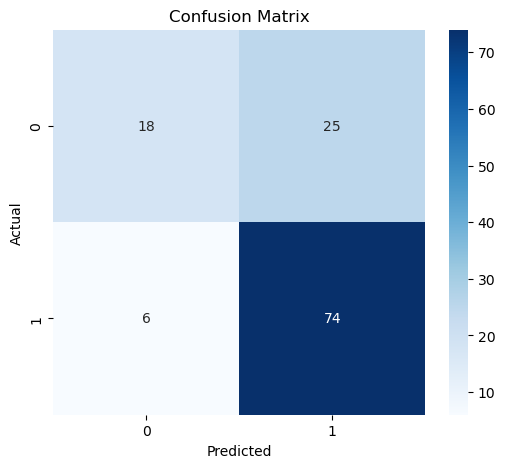

In [19]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.42      0.54        43
           1       0.75      0.93      0.83        80

    accuracy                           0.75       123
   macro avg       0.75      0.67      0.68       123
weighted avg       0.75      0.75      0.73       123



# Business Insights

The model predicts whether a loan application is likely to be approved.

Business benefits include:

- Faster loan processing
- Reduced financial risk
- Better decision support
- Consistent approval process

# Conclusion

This project demonstrated a complete business-first data science workflow.

The workflow included:

- Business Understanding
- Data Cleaning
- Feature Engineering
- Model Training
- Model Evaluation
- Business Interpretation

The model can support financial institutions in making data-driven loan approval decisions.

In [21]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.to_csv(
    "../outputs/loan_predictions.csv",
    index=False
)

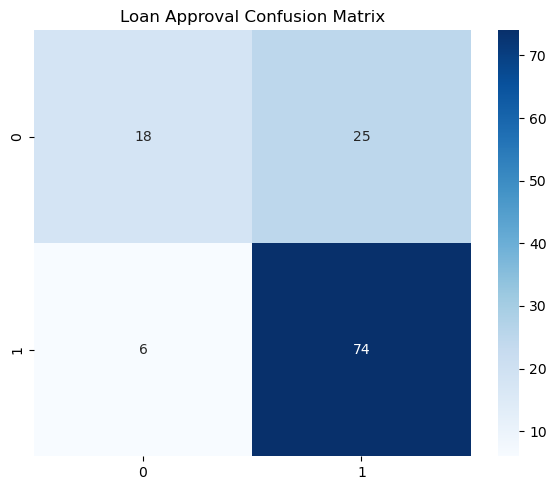

In [22]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Loan Approval Confusion Matrix")

plt.tight_layout()

plt.savefig("../images/confusion_matrix.png")

plt.show()